### Golub–Welsch

Problem:

Find roots and weights of Gauss-Legendre quadrature for a given $N$

$$
    \int_{-1}^{1} f(x) \, dx = \sum_{i = 1}^{N} \, w_i P_{N}(x_i)
$$

Golub–Welsch suggests to solve the eigenvalue problem associated to the matrix $J_N$:

$$
    J_N = \text{ Symmetric Tridiagonal Matrix } \left( 0, 0, \cdots \text{ N times } ; b_1, b_2, \cdots , b_{N - 1}; \right)
$$

Where $b_i = \frac{i}{\sqrt{4 i^2 - 1 }}$.

The eigenvalue of $J_N$ are the roots of $P_N(x)$. The weights $w_i$ can be computed as:

$$
    w_i = \text{ Twice of squared first component of eigenvectors } = 2 \left(v_{0}^{(i)} \right)^2
$$

Let's see it in action

In [1]:
import numpy as np
from numpy.polynomial.legendre import leggauss # Computes roots and weights of Gauss-Legendre quadrature
from scipy.linalg import eigh_tridiagonal # Solves an eigenvalue problem for symmetric tridiagonal matrices
from scipy.integrate import fixed_quad # Gauss-Legendre quadrature using a fixed N
import matplotlib.pyplot as plt

In [2]:
np.set_printoptions(suppress = True) # Suppress engineering notation

In [3]:
def custom_gauss_legendre(N): # Implements Golub–Welsch algorithm

    # First, build the b vector
    i = np.arange(1, N, 1)
    b = i / np.sqrt(4.0 * i ** 2 - 1.0)

    # Second, build the matrix J_N and solve the associated eigenvalue problem
    diagonal_J = np.zeros(N) # J's diagonal is zero
    roots, eigenvectors = eigh_tridiagonal(diagonal_J, b, select = 'a') # Select = 'a' means "find all eigenvalues"

    # Finally, compute weights
    weights = 2.0 * (eigenvectors[0, :]) ** 2

    return roots, weights # Returns roots and weights

Let's compute some values and compare them against *leggauss()* results

In [4]:
custom_gauss_legendre(2), leggauss(2) # N = 2

((array([-0.57735027,  0.57735027]), array([1., 1.])),
 (array([-0.57735027,  0.57735027]), array([1., 1.])))

In [5]:
custom_gauss_legendre(3), leggauss(3) # N = 3

((array([-0.77459667,  0.        ,  0.77459667]),
  array([0.55555556, 0.88888889, 0.55555556])),
 (array([-0.77459667,  0.        ,  0.77459667]),
  array([0.55555556, 0.88888889, 0.55555556])))

In [6]:
custom_gauss_legendre(4), leggauss(4) # N = 4

((array([-0.86113631, -0.33998104,  0.33998104,  0.86113631]),
  array([0.34785485, 0.65214515, 0.65214515, 0.34785485])),
 (array([-0.86113631, -0.33998104,  0.33998104,  0.86113631]),
  array([0.34785485, 0.65214515, 0.65214515, 0.34785485])))

In [7]:
custom_gauss_legendre(5), leggauss(5) # N = 5

((array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985]),
  array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689])),
 (array([-0.90617985, -0.53846931,  0.        ,  0.53846931,  0.90617985]),
  array([0.23692689, 0.47862867, 0.56888889, 0.47862867, 0.23692689])))

In [8]:
custom_gauss_legendre(6),leggauss(6) # N = 6

((array([-0.93246951, -0.66120939, -0.23861919,  0.23861919,  0.66120939,
          0.93246951]),
  array([0.17132449, 0.36076157, 0.46791393, 0.46791393, 0.36076157,
         0.17132449])),
 (array([-0.93246951, -0.66120939, -0.23861919,  0.23861919,  0.66120939,
          0.93246951]),
  array([0.17132449, 0.36076157, 0.46791393, 0.46791393, 0.36076157,
         0.17132449])))

In [9]:
custom_gauss_legendre(7), leggauss(7) # N = 7

((array([-0.94910791, -0.74153119, -0.40584515, -0.        ,  0.40584515,
          0.74153119,  0.94910791]),
  array([0.12948497, 0.27970539, 0.38183005, 0.41795918, 0.38183005,
         0.27970539, 0.12948497])),
 (array([-0.94910791, -0.74153119, -0.40584515,  0.        ,  0.40584515,
          0.74153119,  0.94910791]),
  array([0.12948497, 0.27970539, 0.38183005, 0.41795918, 0.38183005,
         0.27970539, 0.12948497])))

Given a general finite integral:

$$
    I = \int_{a}^{b} f(x) \, dx
$$

Apply the following change of variable:

$$
    x(t) = \frac{a + b}{2} + \frac{b - a}{2} \, t
$$

This trick yields:

$$
    I = \frac{b - a}{2} \, \int_{-1}^{1} f \left(\frac{a + b}{2} + \frac{b - a}{2} \, t \right) \, dt
$$

It can be computed using Gauss-Legendre quadrature:

$$
    I \approx \frac{b - a}{2} \sum_{i = 1}^{N} \, w_i \, f \left(\frac{a + b}{2} + \frac{b - a}{2} \, t_i \right)
$$

Where $t_i$ is the i-th root of $P_N(x)$

In [10]:
def custom_gauss_legendre_integral(f, a, b, N):
    
    roots, weights = custom_gauss_legendre(N) # On [-1, 1]
    
    x = (a + b) / 2.0 + (b - a) / 2.0 * roots # Forward Map
    fx = f(x)
    
    return (b - a) / 2.0 * np.sum(weights * fx) # Integral value

In [11]:
f = lambda x: np.sqrt(x) * np.exp(- x ** 2) / np.log(x + 2.0) # Integrand function (hard)
a, b = 0.0, 3.0 # Range
N = 5 # N = 5

custom_gauss_legendre_integral(f, a, b, N)

np.float64(0.6368858674880069)

In [12]:
fixed_quad(f, a, b, n = N)[0] # Using scipy.integrate.fixed_quad

# It's incredibly close to ours!

np.float64(0.6368858674880066)

Let's see convergence behaviour when $N$ is large

In [13]:
Ns = np.arange(2, 50 + 1, 1)
Is = [custom_gauss_legendre_integral(f, a, b, N) for N in Ns] # I(N) array
Is

[np.float64(0.8308438354583452),
 np.float64(0.6470094904494066),
 np.float64(0.63910530721762),
 np.float64(0.6368858674880069),
 np.float64(0.6344903810507194),
 np.float64(0.6334607886074171),
 np.float64(0.6328523808292993),
 np.float64(0.6324789476399937),
 np.float64(0.6322365591797046),
 np.float64(0.6320723040210271),
 np.float64(0.6319570253786054),
 np.float64(0.6318737219214658),
 np.float64(0.6318120190647596),
 np.float64(0.6317653375890127),
 np.float64(0.631729366120113),
 np.float64(0.6317011982795995),
 np.float64(0.6316788258187799),
 np.float64(0.6316608305611892),
 np.float64(0.6316461915014171),
 np.float64(0.6316341607805744),
 np.float64(0.6316241820461265),
 np.float64(0.6316158355644653),
 np.float64(0.6316088006094607),
 np.float64(0.6316028292398063),
 np.float64(0.6315977277261802),
 np.float64(0.631593343205442),
 np.float64(0.6315895539628248),
 np.float64(0.631586262268846),
 np.float64(0.6315833890392807),
 np.float64(0.6315808698122244),
 np.float64(0.6

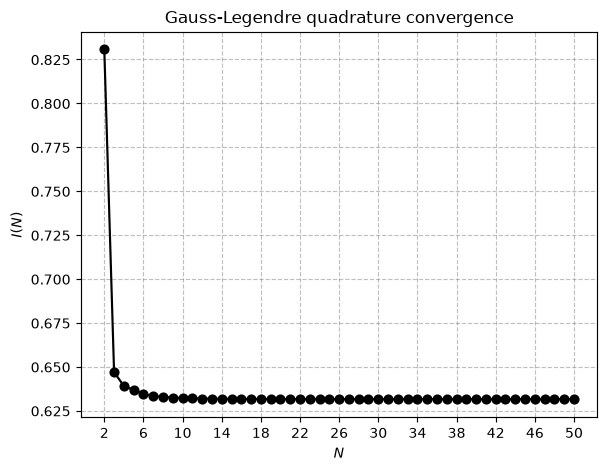

In [14]:
# Plotting Ns vs Is
plt.title('Gauss-Legendre quadrature convergence')
plt.plot(Ns, Is, linestyle = 'solid', marker = 'o', color = 'black')
plt.xlabel(r'$N$')
plt.xticks(Ns[::4])
plt.ylabel(r'$I(N)$')
plt.grid(linestyle = '--', color = 'gray', alpha = 0.5)
plt.show()

May we build an adaptive version...?

In [15]:
def custom_gauss_legendre_integral_adaptive(f, a, b, N0, eps = 1e-06, max_iter = 100): # Adaptive version

    def _gauss_legendre_integral(f, a, b, N):
        roots, weights = leggauss(N) # Using NumPy built-in function to handle large N efficiently
        x = (a + b) / 2.0 + (b - a) / 2.0 * roots # Forward Map
        fx = f(x)
        return (b - a) / 2.0 * np.sum(weights * fx) # Integral value

    for n in range(N0, N0 + max_iter + 1, 1):
    
        I1 = _gauss_legendre_integral(f, a, b, n)
        I2 = _gauss_legendre_integral(f, a, b, n + 1)
        
        err = np.abs(I2 - I1)
        if err < eps:
            print(f"Number of points: {n}")
            break

    else: print("Maximum number of points reached")

    return I1, err

In [16]:
custom_gauss_legendre_integral_adaptive(f, a, b, N0 = 50, eps = 1e-08, max_iter = 100) # Let's try it

Number of points: 123


(np.float64(0.6315565300052356), np.float64(9.796505717751813e-09))

Result ($N = 123$):

$$
    I = 0.63155653 \pm 0.00000001
$$

In [17]:
fixed_quad(f, a, b, n = 123)[0] # Using fixed_quad()

np.float64(0.6315565300052373)